# Numerical solutions to general FRWL universes


*   Cosmology Homework 2: Cosmic Expansion, Computer Assignment
*   Pedro Sáez Díaz s5110998
*   05/10/2025



**(a)** **Derive the expression for the time $t$ for this generic situation.**

We are given that the Hubble parameter $H(t)$ is given by:
\begin{equation}
H(t)=H_0\sqrt{\frac{\Omega_{r,0}}{a^4} + \frac{\Omega_{m,0}}{a^3}+\frac{1-\Omega_0}{a^2}+\Omega_{\Lambda,0}}.
\end{equation}
By definition the Hubbble parameter is related to the expansion factor by $H(t)=\frac{\dot{a}}{a}=\frac{1}{a}\frac{da}{dt}$. Therefore:
\begin{equation}
\frac{1}{a}\frac{da}{dt}=H_0\sqrt{\frac{\Omega_{r,0}}{a^4} + \frac{\Omega_{m,0}}{a^3}+\frac{1-\Omega_0}{a^2}+\Omega_{\Lambda,0}}.
\end{equation}
Multiplying both sides by $a$:
\begin{equation}
\frac{da}{dt} = H_0\sqrt{\frac{\Omega_{r,0}}{a^2} + \frac{\Omega_{m,0}}{a}+(1-\Omega_0)+\Omega_{\Lambda,0}a^2}.
\end{equation}
Solving this differential equation and applying the initial condition that at $t=t_{\text{min}}$, the expansion factor $a(t=t_{\text{min}})=a_\text{min}$ then:
\begin{equation}
\frac{1}{\sqrt{\frac{\Omega_{r,0}}{a^2} + \frac{\Omega_{m,0}}{a}+(1-\Omega_0)+\Omega_{\Lambda,0}a^2}}da = H_0dt \Leftrightarrow
\end{equation}
and performing the integration with the "dummy" variable $x$:

\begin{equation}
\int_{a_\text{min}}^{a}\frac{1}{\sqrt{\frac{\Omega_{r,0}}{x^2} + \frac{\Omega_{m,0}}{x}+(1-\Omega_0)+\Omega_{\Lambda,0}x^2}}dx = \int_{t_\text{min}}^{t}H_0dt =H_0(t-t_\text{min})
\end{equation}


We get the expression for the time $t$ as required:

\begin{equation}
H_0(t-t_\text{min})=
\int_{a_\text{min}}^{a}\frac{1}{\sqrt{\frac{\Omega_{r,0}}{x^2} + \frac{\Omega_{m,0}}{x}+(1-\Omega_0)+\Omega_{\Lambda,0}x^2}}dx
\end{equation}


During this assignment we are going to discard the contribution by radiation ($\Omega_{r,0}=0$): study the behaviour of generic Universes filled with matter and a cosmological constant. Also, we also investigate case in which the universe is not generically
flat.

**(b) To find a solution for a given Universe with matter density $Ω_{m,0}$, cosmological constant contribution $Ω_{Λ,0}$ and curvature dictated by $Ω_0 = Ω_{m,0} +
Ω_{Λ,0}$, you have to numerically integrate the above integral for a range of
values a = [0, 1] (or even further, e.g. a = [0, 10]). You then obtain a
long list of numbers (aj , H0tj ) (j=1,N). Subsequently, invert this relation to
(H0tj , aj ) and make a plot of a(t) vs. t. Write a code that calculates these solutions.**

From part (a) we have that the solution at time $t_j$ where $j\in\{1,...,N\}$ is given by:

\begin{equation}
H_0(t_j-t_\text{min})=
\int_{a_\text{min}}^{a_j}\frac{1}{\sqrt{\frac{\Omega_{r,0}}{x^2} + \frac{\Omega_{m,0}}{x}+(1-\Omega_0)+\Omega_{\Lambda,0}x^2}}dx
\end{equation}

Thus, for each input $j$ we apply quad from scipy.integrate to determine the value of the integral from $a_\text{min}$ to $a_j$, and then we shift the result by adding $H_0t_\text{min}$. The function defined below, $\texttt{general_solution}$ returns the pair $(a_j, H_0t_j)$, where $H_0$, $t_\text{min}$, the grid-size $N$, the interval $[a_\text{min}, a]$ and the values for the densities $\Omega_{m,0}$ and $\Omega_{\Lambda,0}$ are set as input parameters.



In [ ]:
#Import Packages
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

In [ ]:
#Define function that takes different values for the parameters and returns the
#solution pair (a_j, H0t_j) for j=1,...N.

def general_solution(interval_a, N, omega_m, omega_Lambda, H0, t_min):
  "Args: interval_a, N, omega_m, omega_Lambda, H0, t_min"
  "Returns: a(t), H_0t"

  #Ignoring density due to radiation: omega_0 is the sum of the contributions
  #of mass and Lambda:
  omega_0 = omega_m + omega_Lambda

  #Define the range of values of a = [interval_a[0], interval_a[1]]
  values_a = np.linspace(interval_a[0], interval_a[1], N)

  #Define the function to integrate following answer to part (a)
  integrand = lambda x: 1/(np.sqrt(omega_m*(x**-1)+(1-omega_0)+omega_Lambda*(x**2)))
  values_H0_tj = np.zeros_like(values_a)

  #Iterate to determine the solution at each time step
  for i in range(N):
    a_j = values_a[i]
    #Integrate from a_min to a_j
    integral, error = integrate.quad(lambda x: integrand(x), interval_a[0], a_j)
    #Shift the integral to H_0*t_j
    values_H0_tj[i] = integral + H0*t_min
  solution_pairs = np.array([values_a, values_H0_tj])

  return solution_pairs #[values_a, values_H0_tj]

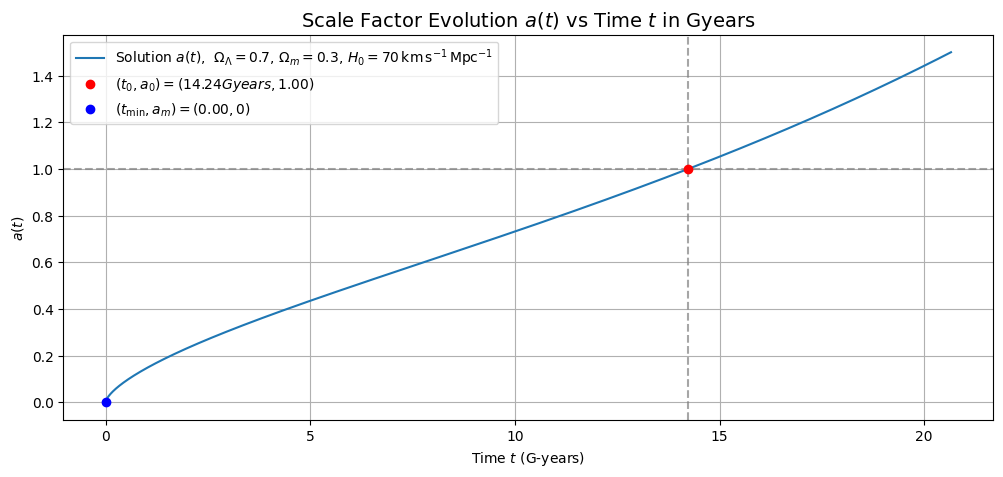

In [ ]:
#Make a plot of a(t) vs t
#Define an arbitrary initial condition

#Set H0 to some value: H0 = 70 kms^-1Mpc^-1
H0 = 70
#Set H0 to SI units
H0_SI = (70*10**3)*(1/(3.26*10**22))

#Determine solution for choice of parameters
solution_pairs_trial = general_solution([1e-8, 1.5], 1000, 0.3, 0.7, H0, 0)
values_t = solution_pairs_trial[1, :]/H0_SI #=(H0*t_j)/H0
values_t_Gyr = values_t/(3.1536*10**16)
values_a = solution_pairs_trial[0, :]

#Set pair (t0, a0)
a0 = 1.0    #Expansion factor today is set to one
#Determine values of a.
values_a_trial = solution_pairs_trial[0,:]
# Find the index of the value of a that is closest to a0
index_a0 = np.argmin(np.abs(values_a - a0))
#This index corresponds to the value H0t_0 in the array containing H0t_j
t0_trial = solution_pairs_trial[1, index_a0]/H0_SI
t0_trial_years = t0_trial/(3.1536*10**16)


#Set the pair (t_min, a_min)
t_min = 0
a_min = 1e-8

fig, ax = plt.subplots(1,1, figsize=(12,5))
ax.plot(values_t_Gyr, values_a, label=r"Solution $a(t)$,  $\Omega_\Lambda={0.7}$, $\Omega_m={0.3}$, $H_0 = {70}\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$")

ax.set_xlabel(r"Time $t$ (G-years)")
ax.set_ylabel(r"$a(t)$")

ax.axvline(x=t0_trial_years, linestyle='--', color='gray', alpha=0.7)
ax.axhline(y=a0, linestyle='--', color='gray', alpha=0.7)

#Point (t0, a0)
ax.plot(t0_trial_years, a0, 'ro', label= fr"$(t_0, a_0) = ({t0_trial_years:.2f}Gyears, {a0:.2f})$")

#Point (t_min, a_min)
ax.plot(t_min, a_min, 'bo', label=fr"$(t_\min, a_m) = ({t_min:.2f}, 0)$")


ax.set_title(r"Scale Factor Evolution $a(t)$ vs Time $t$ in Gyears", fontsize=14)
ax.legend()
ax.grid("True")
plt.show()

From the plot above we indeed get that the solution yields the expected values for today's cosmic parameters: at $t=t_0$ the expasion factor is $a_0=1$ and $H=H_0$ by how the Hubble parameter has been implemented in the code above.  

In [ ]:
#Then we are also asked to plot a(t) vs H0(t-t0) (this defines the time axis)

#We define the function scale_factor_plot that determines t0 and the time axis
#and returns a plot of a(t) vs H0(t-t0) given the solution.

def scale_factor_plot(solution_pairs, H0, omega_m, omega_Lambda, t_min, ax=None):

  #Determine values of a
  values_a = solution_pairs[0,:]
  #Expansion factor today a0 = 1.
  a0 = 1.0
  # Find the index of the value of a that is closest to a0 in values_a
  index_a0 = np.argmin(np.abs(values_a - a0))
  #This index corresponds to the value H0t_0 in the array containing H0t_j
  H0t0 = solution_pairs[1, index_a0]
  #Change H0 to SI and determine age of the universe in Gyears
  H0_SI = (70*10**3)*(1/(3.26*10**22))
  t0_Gyears = H0t0/H0_SI *(1/(3.1536*10**16))

  #Determine time axis H0(t-t0)
  time_axis = solution_pairs[1,:]-H0t0

  #In order to combine multiple outputs in the same graph (for part (e)):
  if ax is None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    ax.plot(0, a0, 'ro', label= fr"$(t_0, a_0) = ({t0_Gyears:.1f} Gyears, {a0:.2f})$")
    ax.plot(t_min*H0-H0t0, a_min, 'bo', label=fr"$(t_\min, a_\min) = ({t_min:.2f}, 0)$")
  else:
    fig = ax.figure

  ax.plot(time_axis, values_a,
        label=rf"Numerical Solution $a(t)$, $\Omega_m={omega_m}$, $\Omega_\Lambda={omega_Lambda}$, $H_0={int(H0)}km/s/Mpc$")

  ax.set_xlabel(r"$H_0(t-t_0)$")
  ax.set_ylabel(r"$a(t)$")

  ax.axvline(x=0, linestyle='--', color='gray', alpha=0.7)
  ax.axhline(y=1, linestyle='--', color='gray', alpha=0.7)

  ax.grid("True")

  return fig, ax

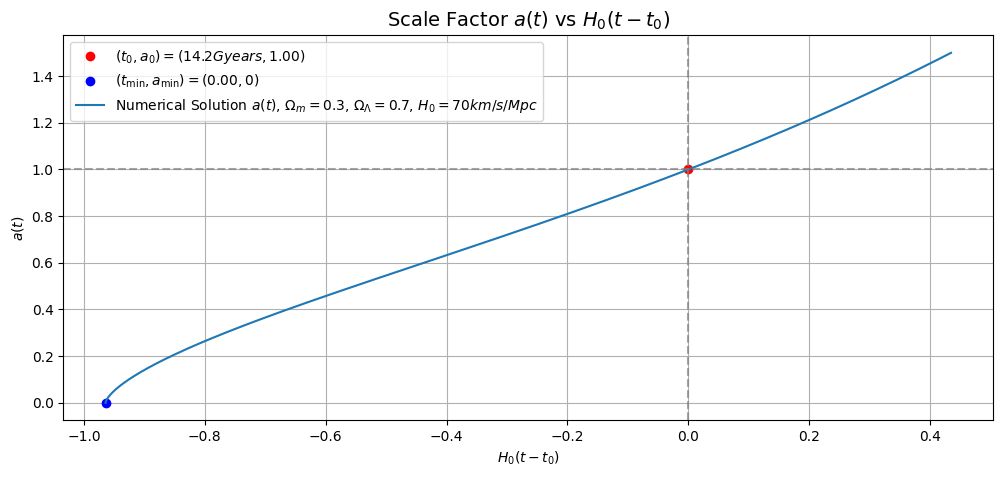

In [ ]:
#Plot of a(t) vs H0(t-t0) for the choice of parameters above
fig, ax = scale_factor_plot(solution_pairs_trial, 70, 0.3, 0.7, 0)

ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$", fontsize=14)
ax.legend()
plt.show()

**(c) Solve numerically the above equation for a range of Universes, and
plot a figure of expansion factor $a(t)$ vs. time $H_0(t−t_0)$. In addition
plot a figure of the age of the Universe ($H_0t$ versus redshift $z$):**
\begin{equation}
z = \frac{1}{a}-1.
\end{equation}

**Flat matter-dominated Universe:**

$\Omega_{m,0}=1$ and $\Omega_{\Lambda,0}=0$

**Compare this to the theoretically derived $a(t)$ for an Einstein-de Sitter
Universe.**


The theoretically derived $a(t)$ for an Einstein-de Sitter Universe (flat and matter-dominated) follows the relationship:
\begin{equation}
a(t) = (\frac{3H_0t}{2})^{2/3}=(\frac{3H_0(t-t_0)+3H_0t_0}{2})^{2/3}
\end{equation}
i.e. $a(t)\propto t^{2/3}$.

Moreover, we know that for an Einstein-de Sitter Universe the a

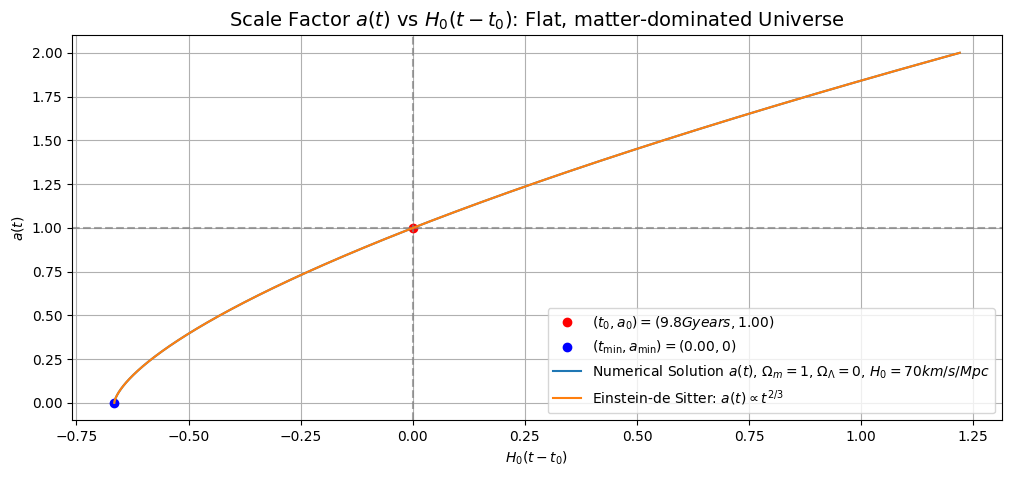

In [ ]:
#We have contribution from matter, and no contribution from Lambda.

#We set the interval of possible values of a: [a_min=1e-9, a]
#Assume that H0 = 70 kms^-1Mpc^-1 and t_min = 0

#The general solution is then:
solution_pairs_matter = general_solution([1e-9, 2], 1000, 1, 0, 70, 0)
#Determine value of t0 and time axis H0(t-t0)
#For that we find the index of the value of a that is closest to a0
index_a0 = np.argmin(np.abs(solution_pairs_matter[0,:] - a0))
H0t0_matter = solution_pairs_matter[1, index_a0]
time_axis_matter = solution_pairs_matter[1,:]-H0t0_matter #H0(t-t0)

#Include the solution for the Einstein-de Sitter Universe
a_EdS = lambda t: ((3*(t)+3*H0t0_matter)/2)**(2/3)
values_a_EdS = a_EdS(time_axis_matter)

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs_matter, 70, 1, 0, 0)

#Plot a(t) for Einstein-de Sitter Universe
ax.plot(time_axis_matter, values_a_EdS, label =r"Einstein-de Sitter: $a(t)\propto t^{2/3}$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat, matter-dominated Universe", fontsize=14)
ax.legend()
plt.show()


Both the numerical solution and the exact solution coincide for a flat, matter-dominated universe, i.e., the Einstein–de Sitter model.

In [ ]:
#Then we are also asked to plot a figure of the age of the Universe:
#H0t vs redshift z.
#We define another function: red_shift_plot

def red_shift_plot(solution_pairs, H0, omega_m, omega_Lambda, a_filter):

  # solution_pairs gives [a_j, H0t_j]
  redshift_z = lambda a: 1/a - 1
  #Apply redshift_z to values of a but ignoring the values very close to zero
  #since redshift blows up to infinity
  a_values = solution_pairs[0,:]
  mask = a_values > a_filter

  #Filter values of a
  a_values_filtered = a_values[mask]

  #Filtered values of H0t_j
  H0t_values_filtered = solution_pairs[1, mask]

  #Determine redshift values
  redshift_values = (redshift_z(a_values_filtered))

  fig, ax = plt.subplots(1,1, figsize=(12,5))
  ax.plot(redshift_values, H0t_values_filtered, color="r",
        label=rf"$H_0t$, $\Omega_m={omega_m}$, $\Omega_\Lambda={omega_Lambda}$, $H_0={int(H0)}$")

  #ax.set_xscale("log")
  ax.set_xlabel(r"redshift $z$")
  ax.set_ylabel(r"$H_0t$")
  ax.grid(True)
  ax.legend()
  return fig, ax

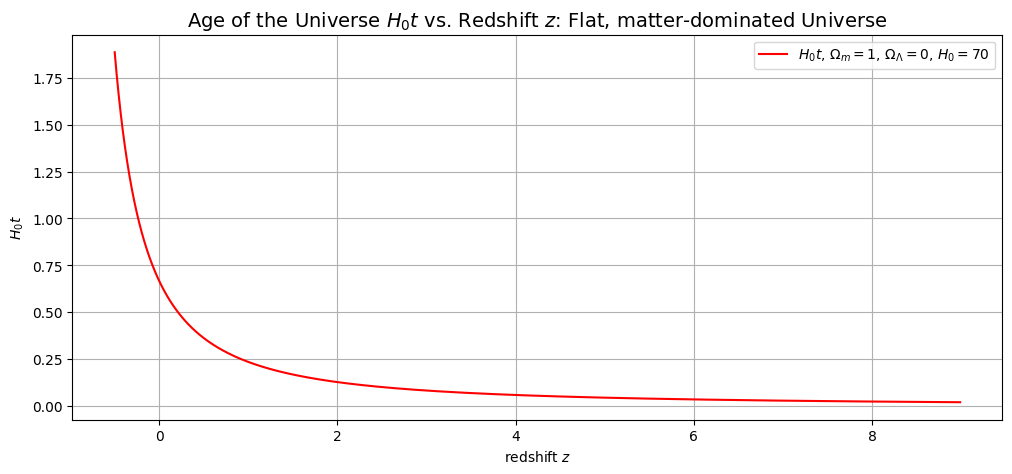

In [ ]:
#Apply red_shift_plot to flat, matter dominated universe
fig, ax = red_shift_plot(solution_pairs_matter, 70, 1, 0, 1e-1)
ax.set_title(r"Age of the Universe $H_0t$ vs. Redshift $z$: Flat, matter-dominated Universe", fontsize=14)
plt.show()


**Flat Lambda-dominated Universe:**

$\Omega_{m,0}=0$ and $\Omega_{\Lambda,0}=1$

**Compare this to the theoretically derived $a(t)$ for a Lambda-dominated
Universe.**


The theoretically derived scale factor $a(t)$ for a Lambda-dominated universe is given by:

\begin{equation}
a(t) = \exp(H(t-t_0)) = \exp(H_0(t-t_0)),
\end{equation}

since we found that for a Lambda-dominated universe the Hubble parameter is constant in time: $H(t)=H_0$.

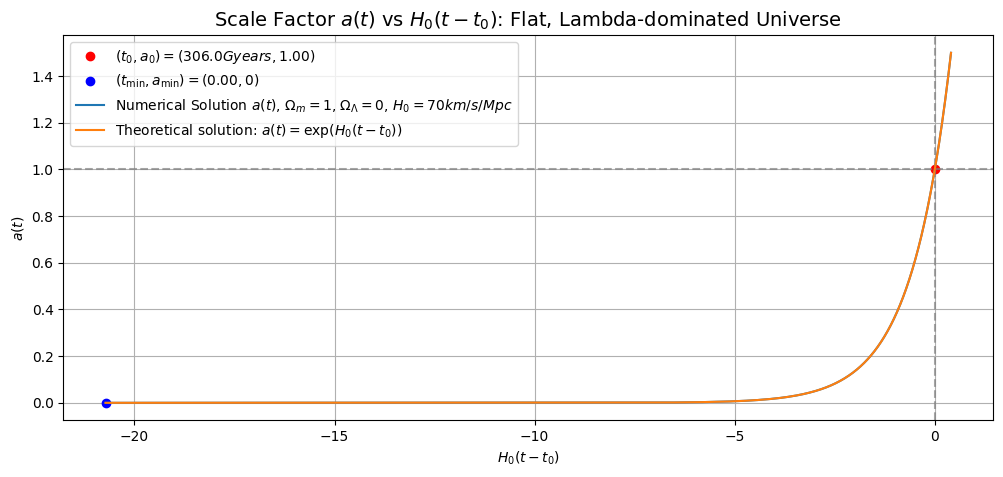

In [ ]:
#Plot for lambda-dominated Universe
#omega_m=0 and omega_lambda=1

#We set the interval of possible values of a: [a_min=0, a0=1]
#Assume that H0 = 70 kms^-1Mpc^-1 and t_min = 0
H0 = 70

#The general solution is then:
solution_pairs_lambda = general_solution([1e-9, 1.5], 1000, 0, 1, 70, 0)
#Determine value of t0 and time axis H0(t-t0)
#Find the index of the value of a that is closest to a0
index_a0 = np.argmin(np.abs(solution_pairs_lambda[0,:] - a0))
H0t0_lambda = solution_pairs_lambda[1, index_a0]
time_axis_lambda = solution_pairs_lambda[1,:]-H0t0_lambda #H0(t-t0)


#Theoretically derived solution for a flat lambda dominated Universe
a_lambda_dom = lambda t: np.exp(t)
values_a_lambda = a_lambda_dom(time_axis_lambda)

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs_lambda, 70, 1, 0, 0)

#Plot a(t) for theoretical scale factor for this Universe
ax.plot(time_axis_lambda, values_a_lambda, label =r"Theoretical solution: $a(t)=\exp(H_0(t-t_0))$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat, Lambda-dominated Universe", fontsize=14)
ax.legend()
plt.show()



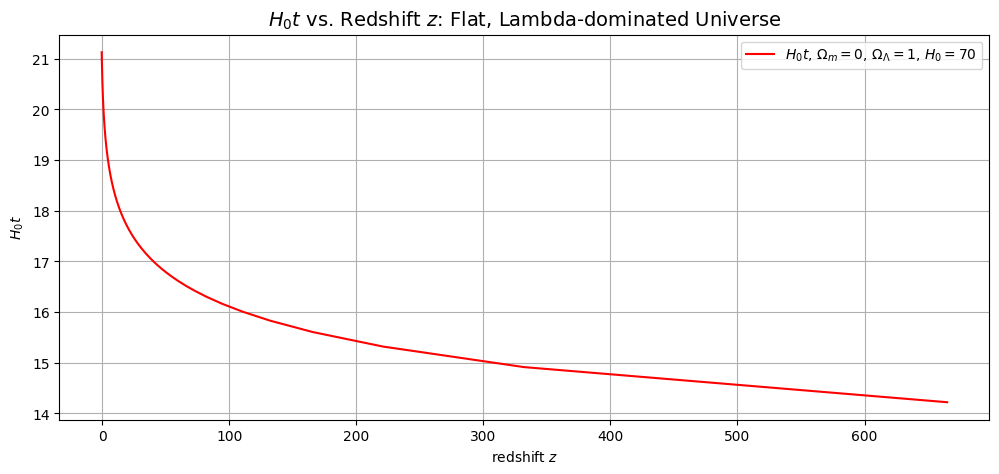

In [ ]:
#Apply red_shift_plot to flat, lambda dominated universe
fig, ax = red_shift_plot(solution_pairs_lambda, 70, 0, 1, a_filter=1e-9)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Flat, Lambda-dominated Universe", fontsize=14)
plt.show()

**Generic flat matter+Lambda Universes:**

$\Omega_{0}=\Omega_{m,0}+\Omega_{\Lambda,0}=1$

**Compare these to the theoretically derived $a(t)$ for flat matter and Lambda
Universes:**
\begin{equation}
H_0t=\frac{2}{\sqrt[3]{1-\Omega_{m,0}}}\ln\{(\frac{a}{a_{m\Lambda}})^{3/2}+\sqrt{1+(\frac{a}{a_{m\Lambda}})^3} \},
\end{equation}

**with**
\begin{equation}
a_{m\Lambda} \equiv (\frac{\Omega_{m,0}}{\Omega_{\Lambda,0}})^{1/3}=(\frac{\Omega_{m,0}}{1-\Omega_{m,0}})^{1/3}.
\end{equation}

In [ ]:
#Throughout this exercise we set the interval of possible values of
# a: [a_min=0, a0=1]
#Assume that H0 = 70 kms^-1Mpc^-1 and t_min = 0


#First we define a function for the theoretically derived
#scale factor for a flat matter and Lambda Universe
def theoretical_mLambda(a, omega_m):
  omega_lambda = 1-omega_m
  a_m_Lambda = (omega_m/omega_lambda)**(1/3)
  H0t0 = 2/(3*np.sqrt(1-omega_m))*(np.log((1/a_m_Lambda)**(3/2)+np.sqrt(1+(1/a_m_Lambda)**3)))
  H0t = 2/(3*np.sqrt(1-omega_m))*(np.log((a/a_m_Lambda)**(3/2)+np.sqrt(1+(a/a_m_Lambda)**3)))
  difference = H0t-H0t0
  return difference

**(i)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.1, 0.9)$

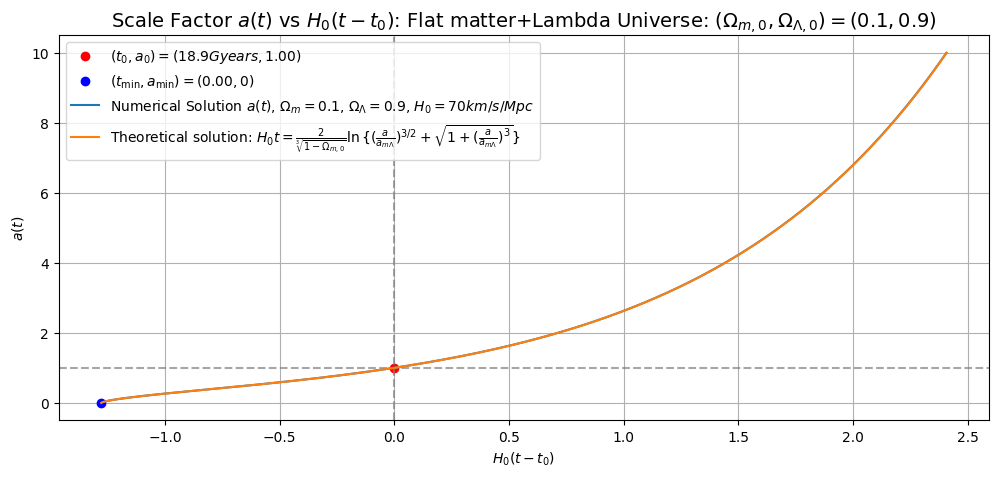

In [ ]:
#The general solution is then:
solution_mLambda_1 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.1, omega_Lambda=0.9, H0=70, t_min=0)


#Theoretically derived solution for generic flat matter+lambda Universe
th_H0t_mLambda_1 = theoretical_mLambda(solution_mLambda_1[0,:], 0.1)
values_a_1 = solution_mLambda_1[0,:]

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_mLambda_1, H0=70, omega_m=0.1,
                            omega_Lambda=0.9, t_min=0)

#Plot a(t) for theoretical scale factor for this Universe
ax.plot(th_H0t_mLambda_1, values_a_1,
        label =r"Theoretical solution: $H_0t=\frac{2}{\sqrt[3]{1-\Omega_{m,0}}}\ln\{(\frac{a}{a_{m\Lambda}})^{3/2}+\sqrt{1+(\frac{a}{a_{m\Lambda}})^3} \}$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.1, 0.9)$",
             fontsize=14)
ax.legend()
plt.show()

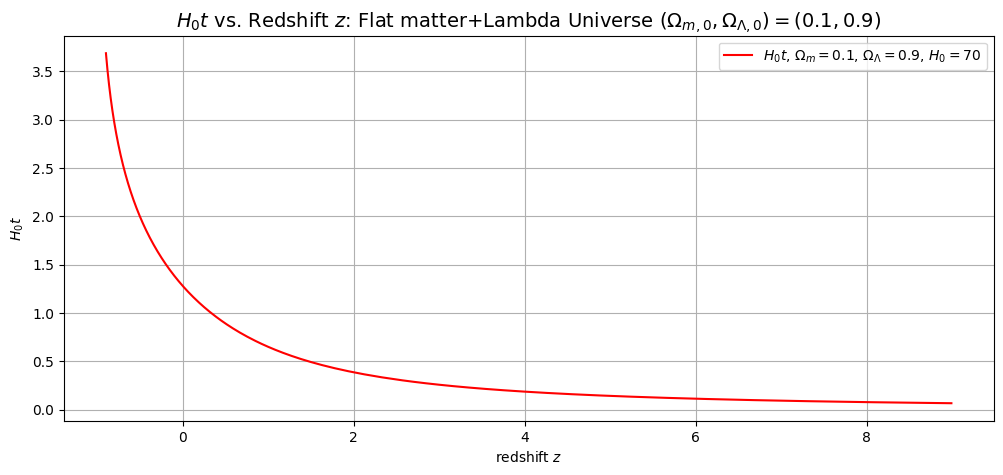

In [ ]:
#Apply red_shift_plot to flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_mLambda_1, 70, 0.1, 0.9, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.1, 0.9)$", fontsize=14)
plt.show()

**(ii)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.27, 0.73)$

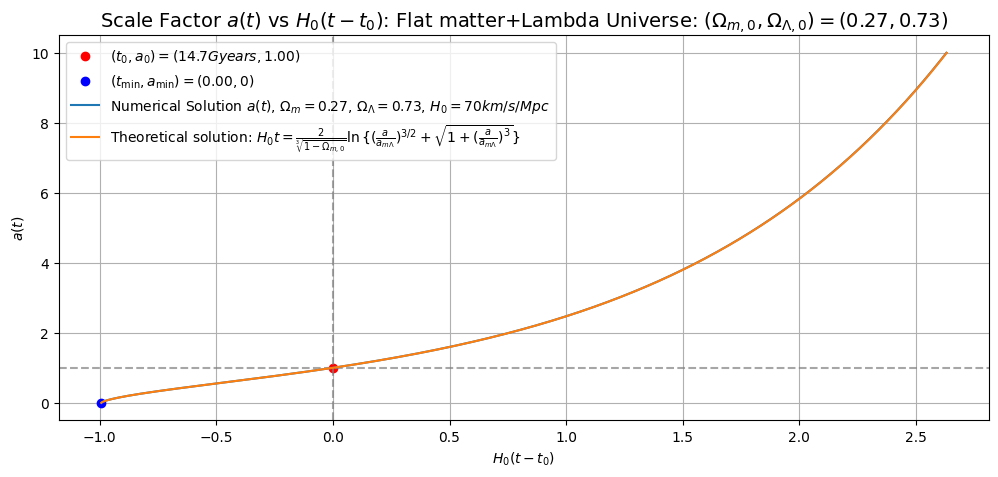

In [ ]:
#The general solution is then:
solution_mLambda_2 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.27, omega_Lambda=0.73, H0=70, t_min=0)


#Theoretically derived solution for generic flat matter+lambda Universe
th_H0t_mLambda_2 = theoretical_mLambda(solution_mLambda_2[0,:], 0.27)
values_a_2 = solution_mLambda_2[0,:]

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_mLambda_2, H0=70, omega_m=0.27,
                            omega_Lambda=0.73, t_min=0)

#Plot a(t) for theoretical scale factor for this Universe
ax.plot(th_H0t_mLambda_2, values_a_2,
        label =r"Theoretical solution: $H_0t=\frac{2}{\sqrt[3]{1-\Omega_{m,0}}}\ln\{(\frac{a}{a_{m\Lambda}})^{3/2}+\sqrt{1+(\frac{a}{a_{m\Lambda}})^3} \}$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.27, 0.73)$",
             fontsize=14)
ax.legend()
plt.show()

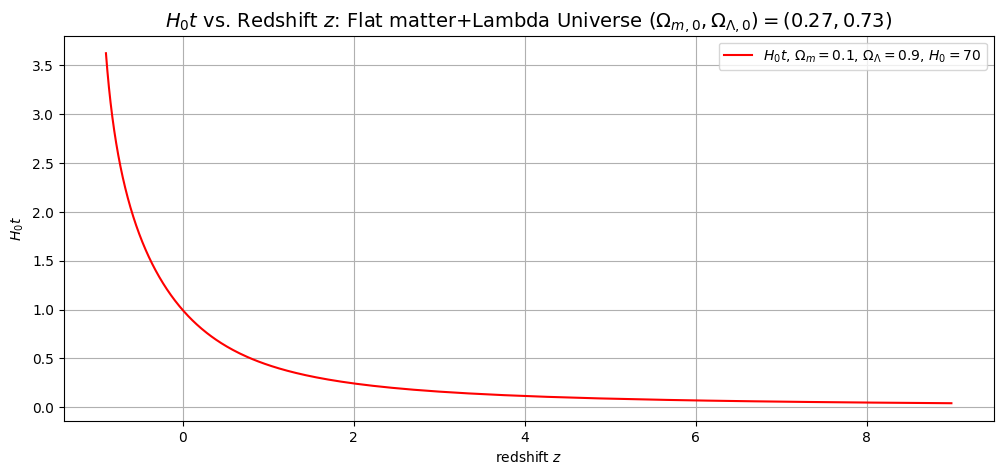

In [ ]:
#Apply red_shift_plot to flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_mLambda_2, 70, 0.1, 0.9, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.27, 0.73)$", fontsize=14)
plt.show()

**(iii)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.5, 0.5)$

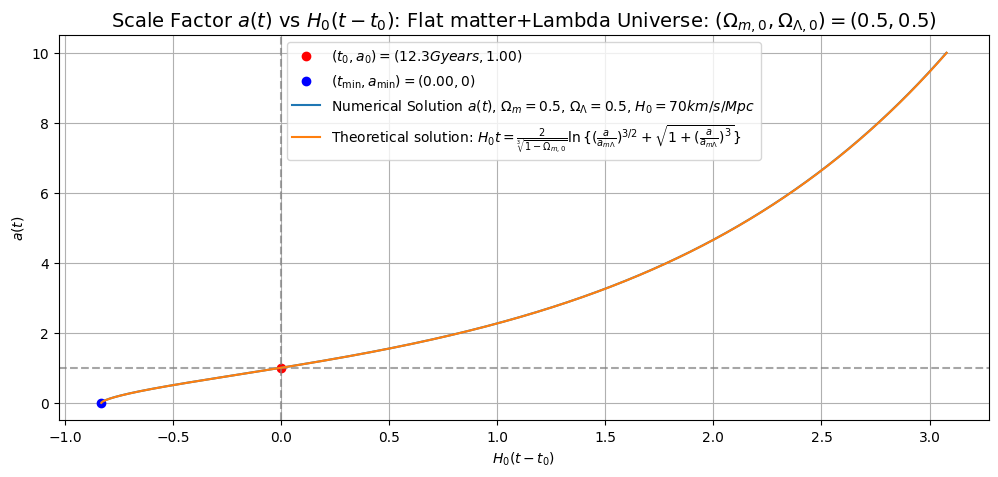

In [ ]:
#The general solution is then:
solution_mLambda_3 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.5, omega_Lambda=0.5, H0=70, t_min=0)

#Theoretically derived solution for generic flat matter+lambda Universe
th_H0t_mLambda_3 = theoretical_mLambda(solution_mLambda_3[0,:], 0.5)
values_a_3 = solution_mLambda_3[0,:]

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_mLambda_3, H0=70, omega_m=0.5,
                            omega_Lambda=0.5, t_min=0)

#Plot a(t) for theoretical scale factor for this Universe
ax.plot(th_H0t_mLambda_3, values_a_3,
        label =r"Theoretical solution: $H_0t=\frac{2}{\sqrt[3]{1-\Omega_{m,0}}}\ln\{(\frac{a}{a_{m\Lambda}})^{3/2}+\sqrt{1+(\frac{a}{a_{m\Lambda}})^3} \}$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.5, 0.5)$",
             fontsize=14)
ax.legend()
plt.show()

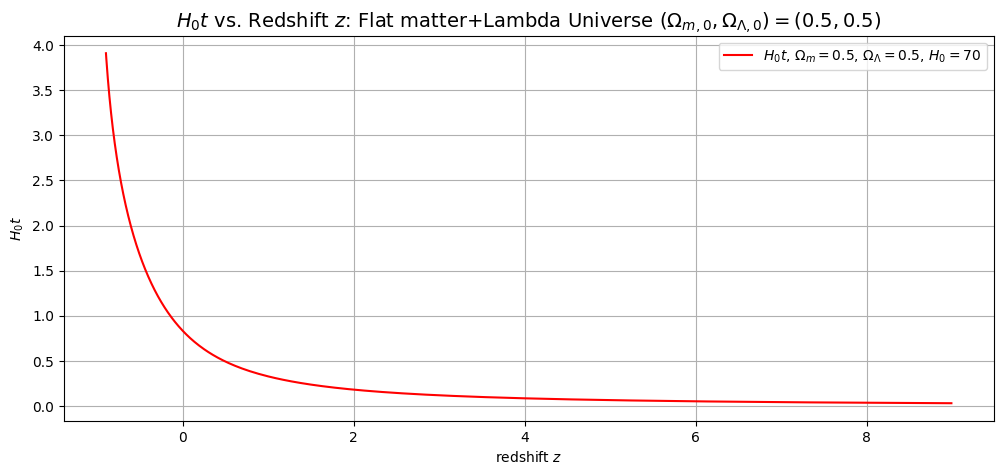

In [ ]:
#Apply red_shift_plot to flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_mLambda_3, 70, 0.5, 0.5, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.5, 0.5)$", fontsize=14)
plt.show()

**(iv)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.75, 0.25)$

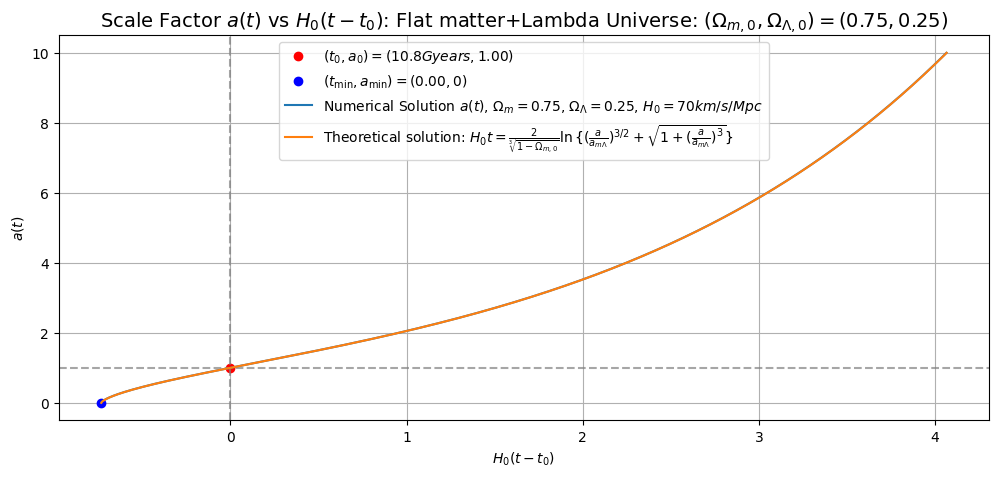

In [ ]:
#The general solution is then:
solution_mLambda_4 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.75, omega_Lambda=0.25, H0=70, t_min=0)

#Theoretically derived solution for generic flat matter+lambda Universe
th_H0t_mLambda_4 = theoretical_mLambda(solution_mLambda_4[0,:], 0.75)
values_a_4 = solution_mLambda_4[0,:]

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_mLambda_4, H0=70, omega_m=0.75,
                            omega_Lambda=0.25, t_min=0)

#Plot a(t) for theoretical scale factor for this Universe
ax.plot(th_H0t_mLambda_4, values_a_4,
        label =r"Theoretical solution: $H_0t=\frac{2}{\sqrt[3]{1-\Omega_{m,0}}}\ln\{(\frac{a}{a_{m\Lambda}})^{3/2}+\sqrt{1+(\frac{a}{a_{m\Lambda}})^3} \}$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.75, 0.25)$",
             fontsize=14)
ax.legend()
plt.show()

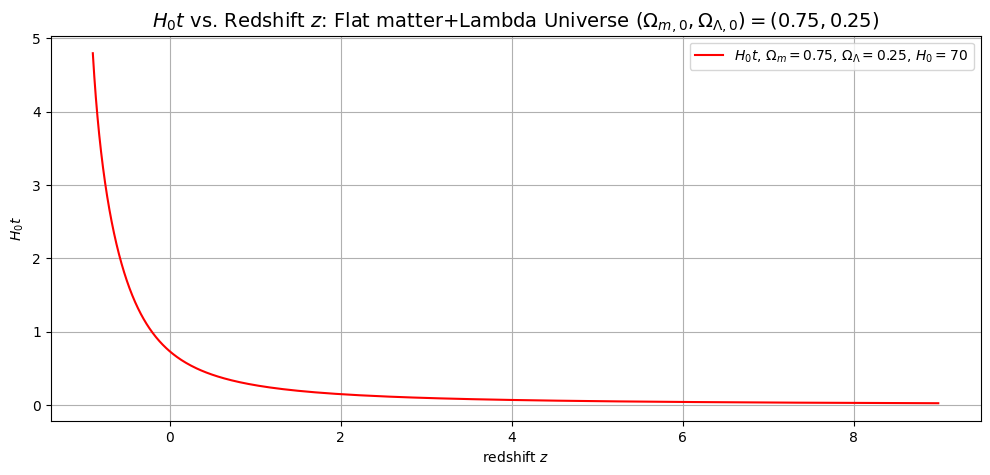

In [ ]:
#Apply red_shift_plot to flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_mLambda_4, 70, 0.75, 0.25, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.75, 0.25)$", fontsize=14)
plt.show()

**(v)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.9, 0.1)$

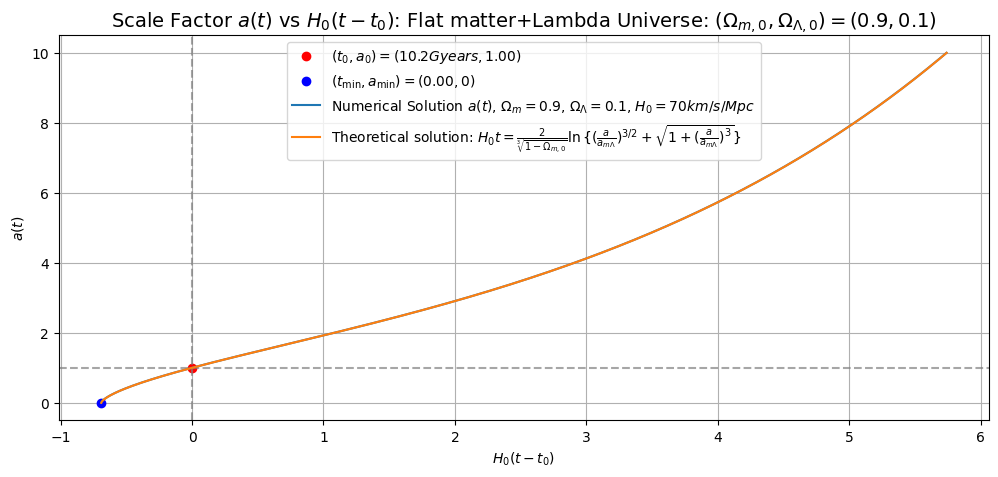

In [ ]:
#The general solution is then:
solution_mLambda_5 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.9, omega_Lambda=0.1, H0=70, t_min=0)

#Theoretically derived solution for generic flat matter+lambda Universe
th_H0t_mLambda_5 = theoretical_mLambda(solution_mLambda_5[0,:], 0.9)
values_a_5 = solution_mLambda_5[0,:]

#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_mLambda_5, H0=70, omega_m=0.9,
                            omega_Lambda=0.1, t_min=0)

#Plot a(t) for theoretical scale factor for this Universe
ax.plot(th_H0t_mLambda_5, values_a_5,
        label =r"Theoretical solution: $H_0t=\frac{2}{\sqrt[3]{1-\Omega_{m,0}}}\ln\{(\frac{a}{a_{m\Lambda}})^{3/2}+\sqrt{1+(\frac{a}{a_{m\Lambda}})^3} \}$")


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.9, 0.1)$",
             fontsize=14)
ax.legend()
plt.show()

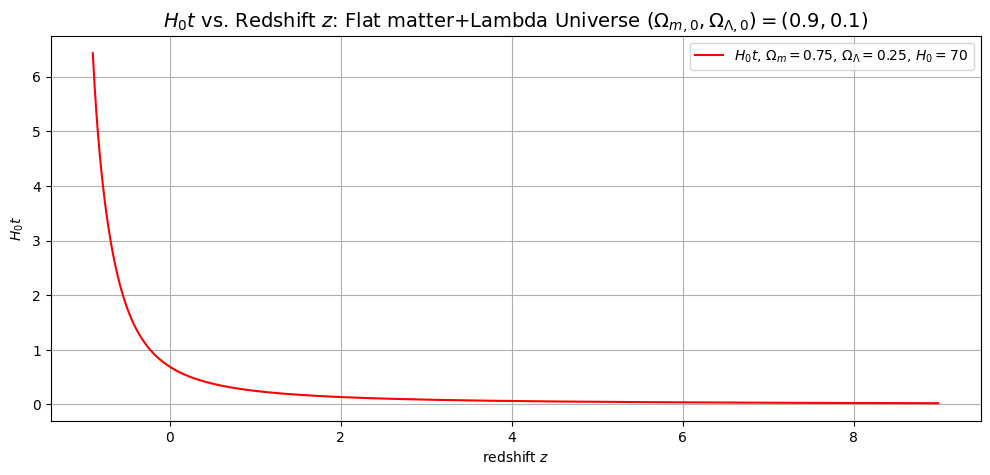

In [ ]:
#Apply red_shift_plot to flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_mLambda_5, 70, 0.75, 0.25, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.9, 0.1)$", fontsize=14)
plt.show()

**Generic non-flat Universe:**

There is no simple closed-form solution for the generic non-flat universe. Thus, we only plot the numerical solutions.

**(i)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (1.0, 0.3)$

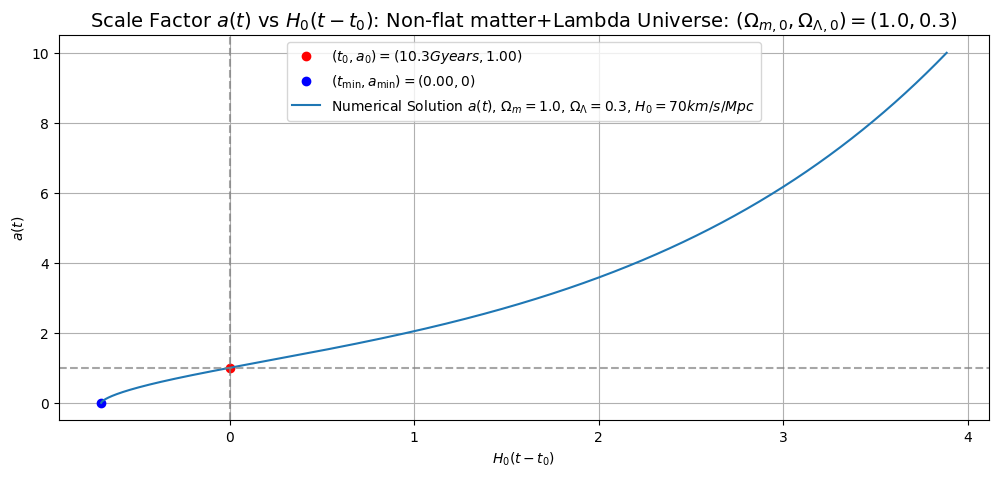

In [ ]:
#The general solution is then:
solution_nonflat_1 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=1.0, omega_Lambda=0.3, H0=70, t_min=0)


#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_nonflat_1, H0=70, omega_m=1.0,
                            omega_Lambda=0.3, t_min=0)


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Non-flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1.0, 0.3)$",
             fontsize=14)
ax.legend()
plt.show()

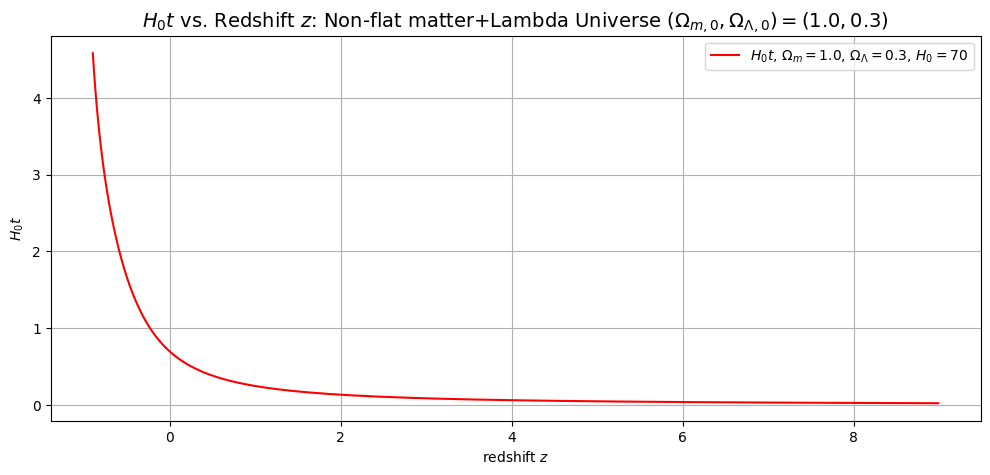

In [ ]:
#Apply red_shift_plot to non-flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_nonflat_1, 70, 1.0, 0.3, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Non-flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1.0, 0.3)$", fontsize=14)
plt.show()

**(ii)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (1.0, 0.5)$

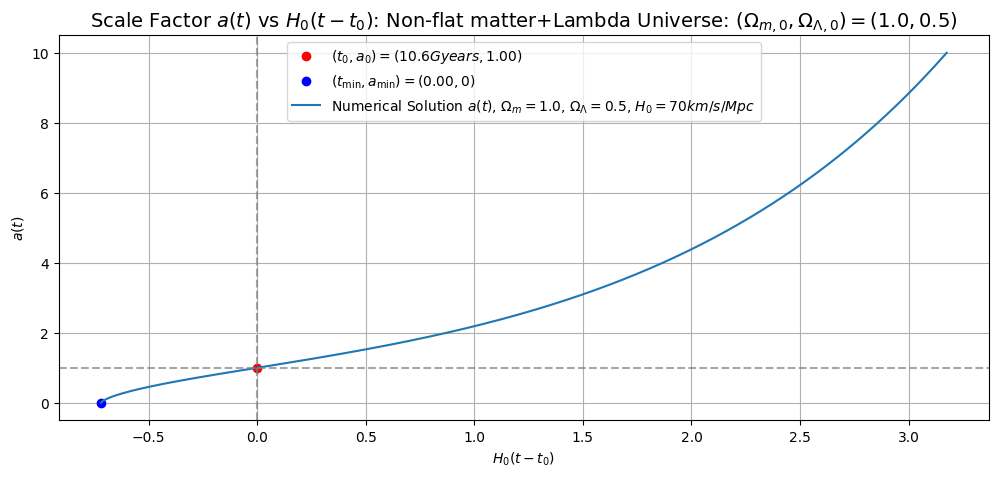

In [ ]:
#The general solution is then:
solution_nonflat_2 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=1.0, omega_Lambda=0.5, H0=70, t_min=0)


#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_nonflat_2, H0=70, omega_m=1.0,
                            omega_Lambda=0.5, t_min=0)


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Non-flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1.0, 0.5)$",
             fontsize=14)
ax.legend()
plt.show()

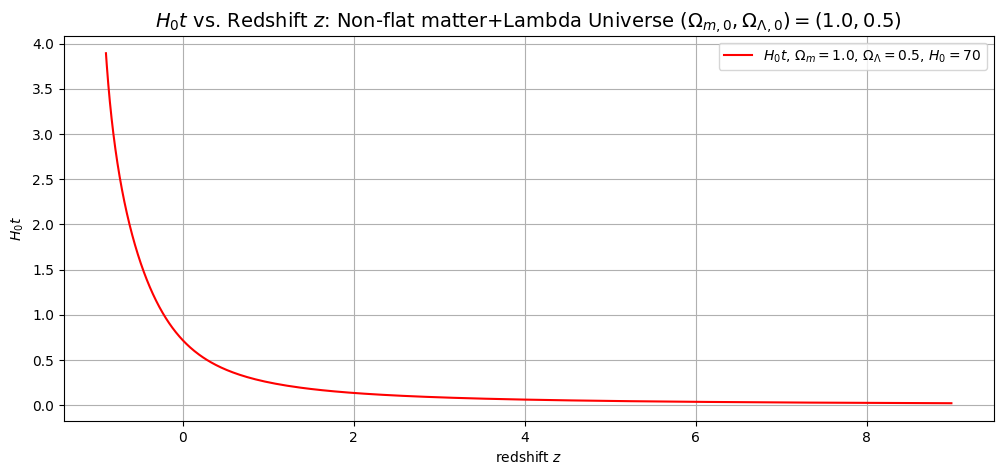

In [ ]:
#Apply red_shift_plot to non-flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_nonflat_2, 70, 1.0, 0.5, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Non-flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1.0, 0.5)$", fontsize=14)
plt.show()

**(iii)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (1.0, 1.0)$

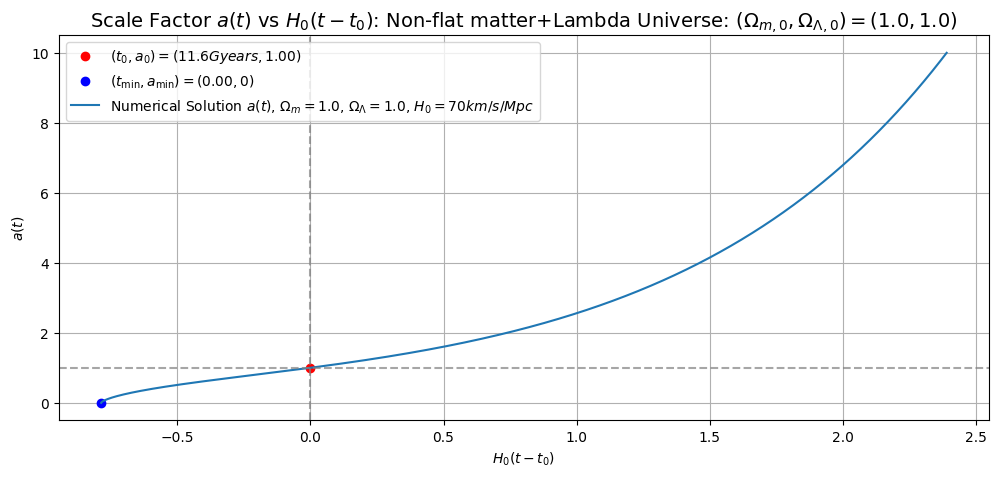

In [ ]:
#The general solution is then:
solution_nonflat_3 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=1.0, omega_Lambda=1.0, H0=70, t_min=0)


#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_nonflat_3, H0=70, omega_m=1.0,
                            omega_Lambda=1.0, t_min=0)


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Non-flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1.0, 1.0)$",
             fontsize=14)
ax.legend()
plt.show()

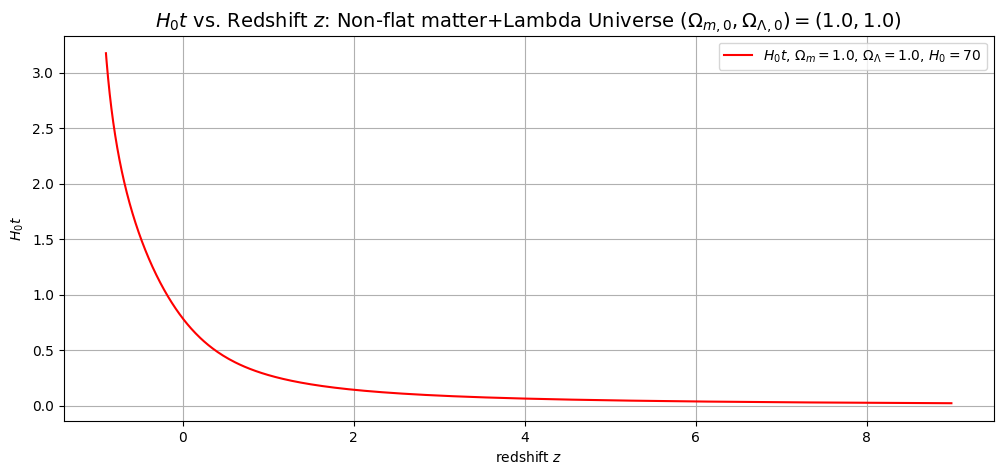

In [ ]:
#Apply red_shift_plot to non-flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_nonflat_3, 70, 1.0, 1.0, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Non-flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1.0, 1.0)$", fontsize=14)
plt.show()

**(iv)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.3, 0.15)$

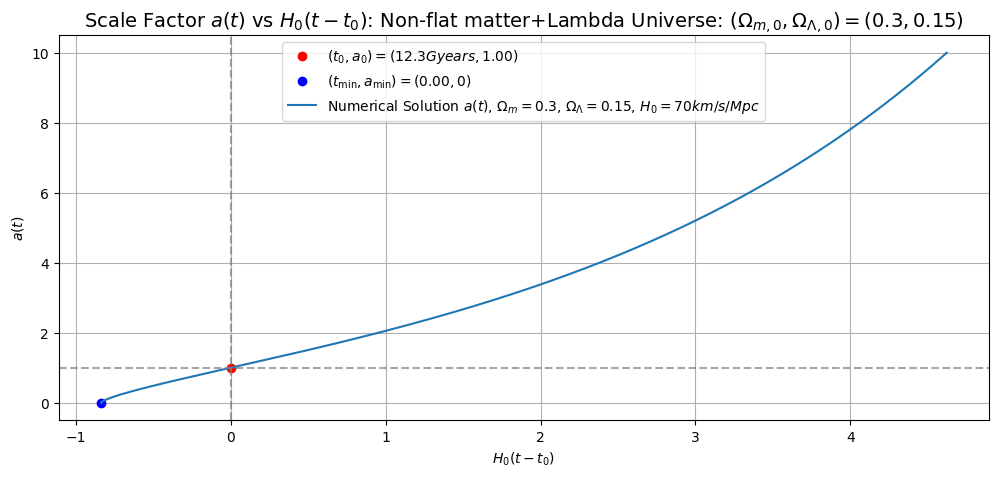

In [ ]:
#The general solution is then:
solution_nonflat_4 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.3, omega_Lambda=0.15, H0=70, t_min=0)


#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_nonflat_4, H0=70, omega_m=0.3,
                            omega_Lambda=0.15, t_min=0)


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Non-flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.3, 0.15)$",
             fontsize=14)
ax.legend()
plt.show()

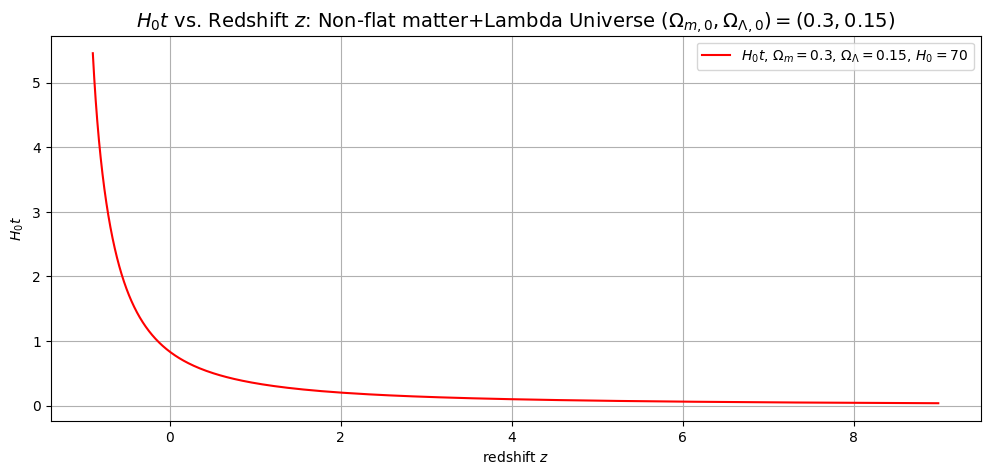

In [ ]:
#Apply red_shift_plot to non-flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_nonflat_4, 70, 0.3, 0.15, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Non-flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.3, 0.15)$", fontsize=14)
plt.show()

**(v)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.3, 0.3)$

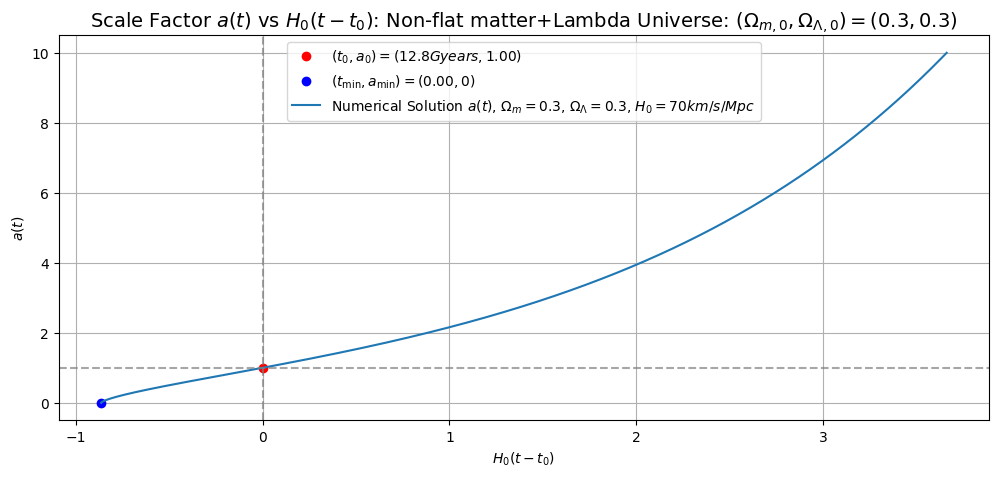

In [ ]:
#The general solution is then:
solution_nonflat_5 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.3, omega_Lambda=0.3, H0=70, t_min=0)


#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_nonflat_5, H0=70, omega_m=0.3,
                            omega_Lambda=0.3, t_min=0)


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Non-flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.3, 0.3)$",
             fontsize=14)
ax.legend()
plt.show()

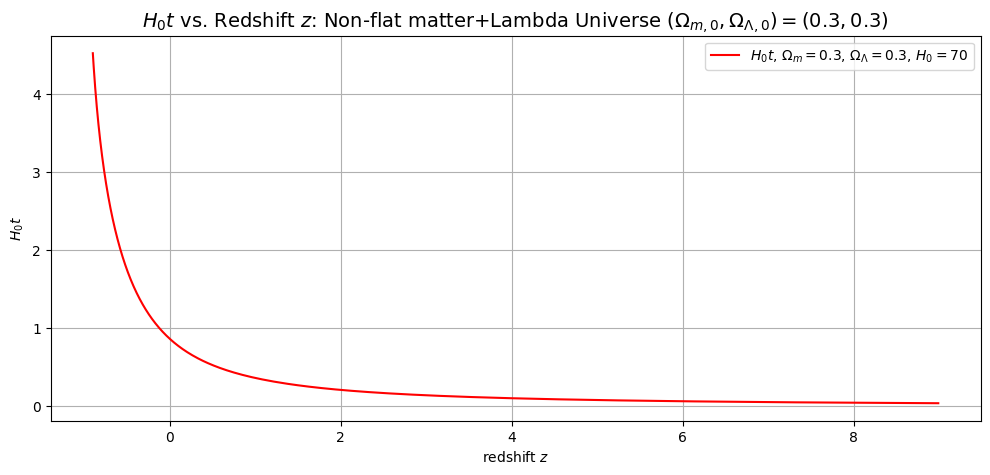

In [ ]:
#Apply red_shift_plot to non-flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_nonflat_5, 70, 0.3, 0.3, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Non-flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.3, 0.3)$", fontsize=14)
plt.show()

**(vi)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.3, 1.0)$

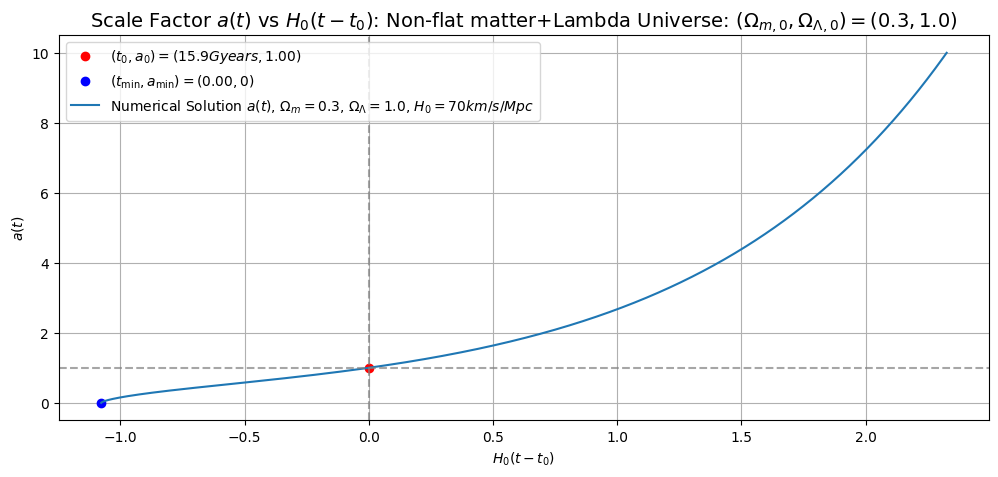

In [ ]:
#The general solution is then:
solution_nonflat_6 = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=0.3, omega_Lambda=1.0, H0=70, t_min=0)


#Plot figure of expansion factor vs H0(t-t0)
fig, ax = scale_factor_plot(solution_pairs=solution_nonflat_6, H0=70, omega_m=0.3,
                            omega_Lambda=1.0, t_min=0)


ax.set_title(r"Scale Factor $a(t)$ vs $H_0(t-t_0)$: Non-flat matter+Lambda Universe: $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.3, 1.0)$",
             fontsize=14)
ax.legend()
plt.show()

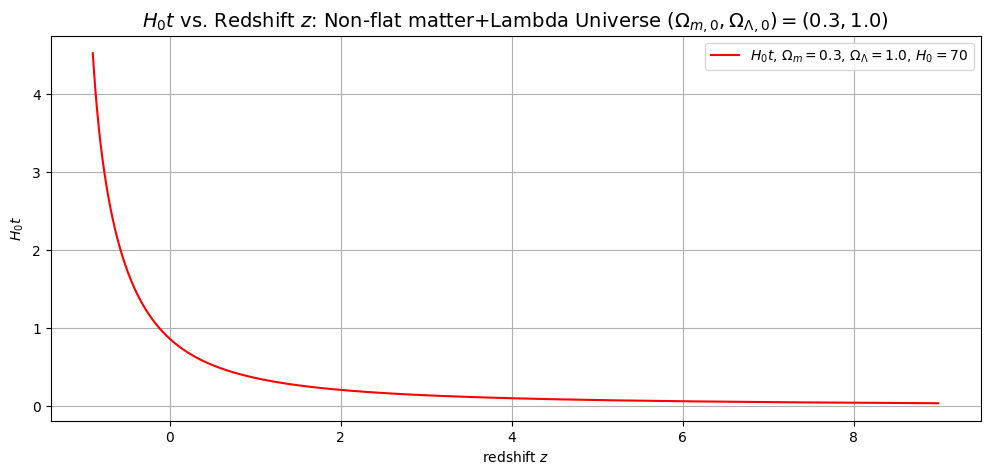

In [ ]:
#Apply red_shift_plot to non-flat, matter+Lambda Universe
fig, ax = red_shift_plot(solution_nonflat_5, 70, 0.3, 1.0, 1e-1)
ax.set_title(r"$H_0t$ vs. Redshift $z$: Non-flat matter+Lambda Universe $(\Omega_{m,0}, \Omega_{\Lambda,0}) = (0.3, 1.0)$", fontsize=14)
plt.show()

**(e) For comparison, also present a figure in which all calculated generic
flatter matter+lambda universe solutions are plotted. Give a critical
discussion on the comparison between the various models.**

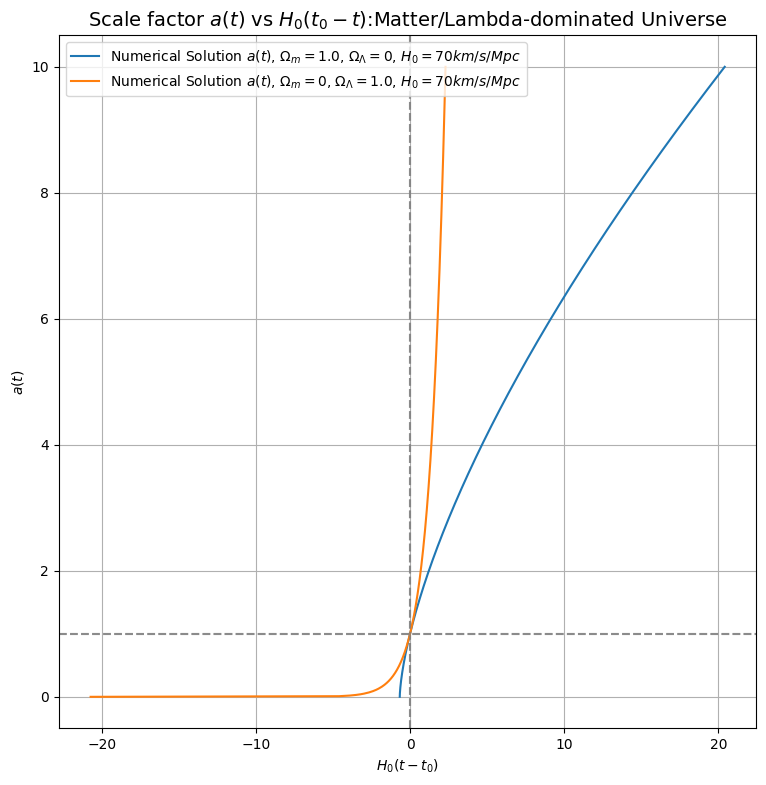

In [ ]:
#Here we plot together the solution for the flat matter-dominated universe and
#the flat Lambda-dominated universe.
fig, ax = plt.subplots(1,1, figsize=(9,9))

#Include the matter-dominated and Lambda-dominated solutions (k=0)
#Matter dominated:
solution_matter = general_solution(interval_a=[1e-9, 10], N=1000, omega_m=1.0,
                                      omega_Lambda=0, H0=70, t_min=0)

scale_factor_plot(solution_pairs=solution_matter, H0=70, omega_m=1.0,
                            omega_Lambda=0, t_min=0, ax=ax)

#Lambda dominated
solution_lambda = general_solution(interval_a=[1e-9, 10], N=1000, omega_m=0,
                                      omega_Lambda=1, H0=70, t_min=0)

scale_factor_plot(solution_pairs=solution_lambda, H0=70, omega_m=0,
                            omega_Lambda=1.0, t_min=0, ax=ax)

ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$:Matter/Lambda-dominated Universe", fontsize=14)
ax.legend()
plt.show()

This plot is comparing the solution for a matter-dominated Universe (Einstein de Sitter) and a Lambda dominated (de Sitter) Universe. The Einstein–de Sitter model exhibits a decelerating expansion, as the attractive gravitational effect of matter dominates, slowing down the rate of expansion. The Lambda-dominated universe shows an accelerating expansion, due to the repulsive effect of dark energy. The flat matter– Lambda models plotted below show intermediate cases between these two asymptotic behaviors: they begin with matter-dominated deceleration and eventually transition to dark-energy acceleration at late times.

Plot considering flat universes:

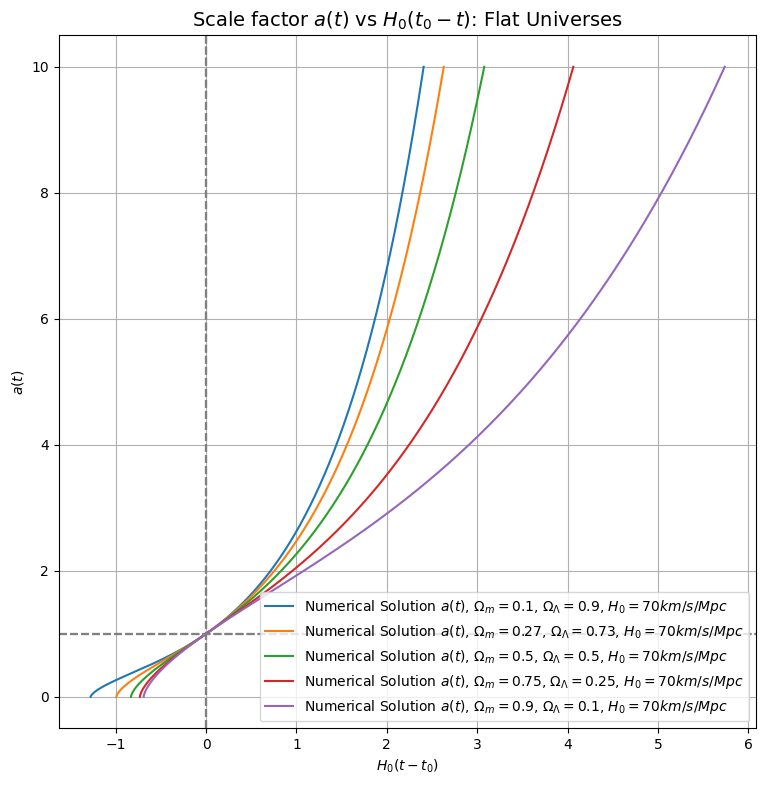

In [ ]:
#Here we plot together all solutions for flat matter+lambda universes.
fig, ax = plt.subplots(1,1, figsize=(9,9))

#Plot all solutions (flat Universes)

scale_factor_plot(solution_pairs=solution_mLambda_1, H0=70, omega_m=0.1,
                            omega_Lambda=0.9, t_min=0, ax=ax) #(i)
scale_factor_plot(solution_pairs=solution_mLambda_2, H0=70, omega_m=0.27,
                            omega_Lambda=0.73, t_min=0, ax=ax) #(ii)

scale_factor_plot(solution_pairs=solution_mLambda_3, H0=70, omega_m=0.5,
                            omega_Lambda=0.5, t_min=0, ax=ax) #(iii)

scale_factor_plot(solution_pairs=solution_mLambda_4, H0=70, omega_m=0.75,
                            omega_Lambda=0.25, t_min=0, ax=ax) #(iv)

scale_factor_plot(solution_pairs=solution_mLambda_5, H0=70, omega_m=0.9,
                            omega_Lambda=0.1, t_min=0, ax=ax) #(v)

ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Flat Universes", fontsize=14)
ax.legend()
plt.show()


First of all, during the construction of these models, we do not consider the contribution of radiation. If we were to consider $\Omega_r \neq 0$ then the universe would be radiation dominated up until $a(t)=a_{rm}$: the point in time at which the radiation-matter transition occurs. This would imply a behaviour of $a(t)=\sqrt{2H_0t}$ for very low values of $a$ as derived in Homework 1.  


Looking at the figure above, we may note that each plot for the solution $a(t)$ has different values for which $a(t_\text{min})=0$. This means that each solution (i.e. each choice of the paramters $\Omega_{m,0}$ and $\Omega_{\Lambda,0}$) yield different ages for each of the Universes considered.


For low values of the scale factor $a(t)$ all graphs have a similar shape, close to that of the graph of $t^{2/3}$ vs $t$. This follows from the fact that at early stages of the universe the influence of matter is most relevant, since
we derived that the matter-density behaves as $\rho_m=\rho_{m,0}a^{-3}$ while that of dark energy remains constant in time: $\rho_\Lambda=\rho_{\Lambda,0}$. Therefore, for low values of $a(t)$, the solutions exhibit a similar behaviour to that of purely matter-dominated Universe (i.e. an Einstein de Sitter Universe) where $a(t)\propto t^{2/3}$. Thus, the expasion of the universe is also decelerating.


Another important fact is that all plots are made such that at $t_0$ the scale factor today is equal to one ($a_0=1$). This sets an initial condition on the solution to the Friedman Walker equations from which this model is derived.

Then, following the relations $\rho_m=\rho_{m,0}a^{-3}$ and $\rho_\Lambda=\rho_{\Lambda,0}$, as time increases, the contribution due to matter decreases, while that of lambda remains constant in time. At some point, which depends on the initial parameter $\Omega_\lambda$ inserted in for the solution, the effects of dark energy become more significant than those of matter. This is known as the matter-dark energy transition: $a(t_{m,\Lambda})=a_{m,\Lambda}=\sqrt[3]{\Omega_{m,0}/2\Omega_{\Lambda,0}}$.

The solutions then become approximately equal to that of a Lambda-dominated universe: the expansion becomes exponentially accelerated $a(t)=e^{H_0(t-t_0)}$. This can be easily seen in the graph above: at some point the solution changes from being concave downwards (suggesting a decelerated expansion) to concave upwards (suggesting an accelerated expansion). The time at which this change occurs (at which the deleceration parameter $q$ changes sign) is different for the different initial parameters of $\Omega_{m,0}$ and $\Omega_{\Lambda,0}$. The graphs below then show an exponential behaviour in $a(t)$ as $t→∞$ following $a(t)=e^{H_0(t-t_0)}$.

Plot considering non-flat universes:


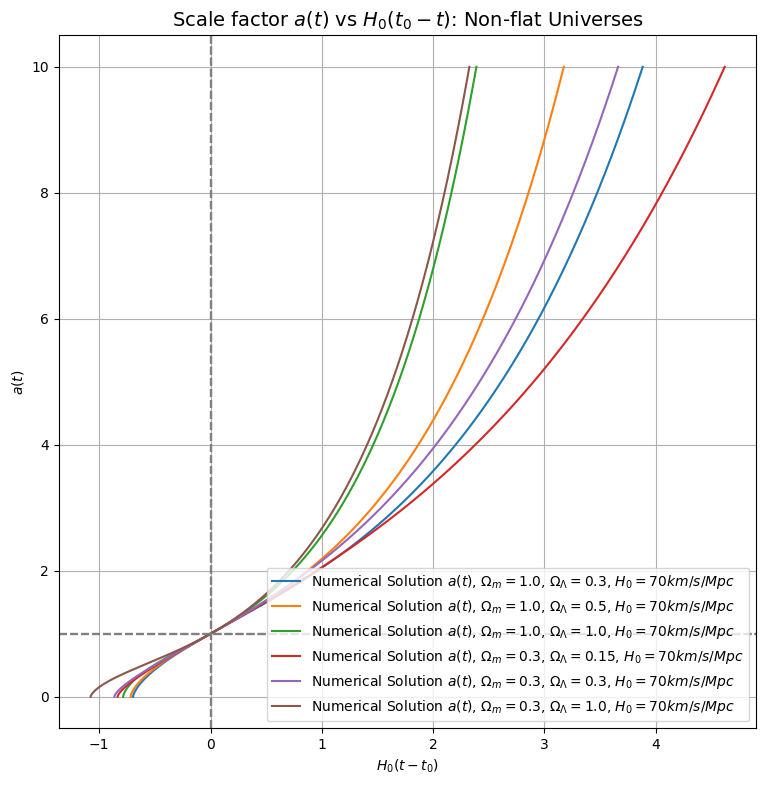

In [ ]:
#Here we plot together all solutions for non-flat matter+lambda universes.
fig, ax = plt.subplots(1,1, figsize=(9,9))

#Plot all solutions (Non-flat Universes):
scale_factor_plot(solution_pairs=solution_nonflat_1, H0=70, omega_m=1.0,
                            omega_Lambda=0.3, t_min=0, ax=ax) #(i)

scale_factor_plot(solution_pairs=solution_nonflat_2, H0=70, omega_m=1.0,
                            omega_Lambda=0.5, t_min=0, ax=ax) #(ii)

scale_factor_plot(solution_pairs=solution_nonflat_3, H0=70, omega_m=1.0,
                            omega_Lambda=1.0, t_min=0, ax=ax) #(iii)

scale_factor_plot(solution_pairs=solution_nonflat_4, H0=70, omega_m=0.3,
                            omega_Lambda=0.15, t_min=0, ax=ax) #(iv)

scale_factor_plot(solution_pairs=solution_nonflat_5, H0=70, omega_m=0.3,
                            omega_Lambda=0.3, t_min=0, ax=ax) #(v)

scale_factor_plot(solution_pairs=solution_nonflat_6, H0=70, omega_m=0.3,
                            omega_Lambda=1.0, t_min=0, ax=ax) #(vi)

ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Non-flat Universes",
             fontsize=14)
ax.legend()
plt.show()


Plot considering all studied solutions in (c) and (d) (i.e. flat and non-flat universes).

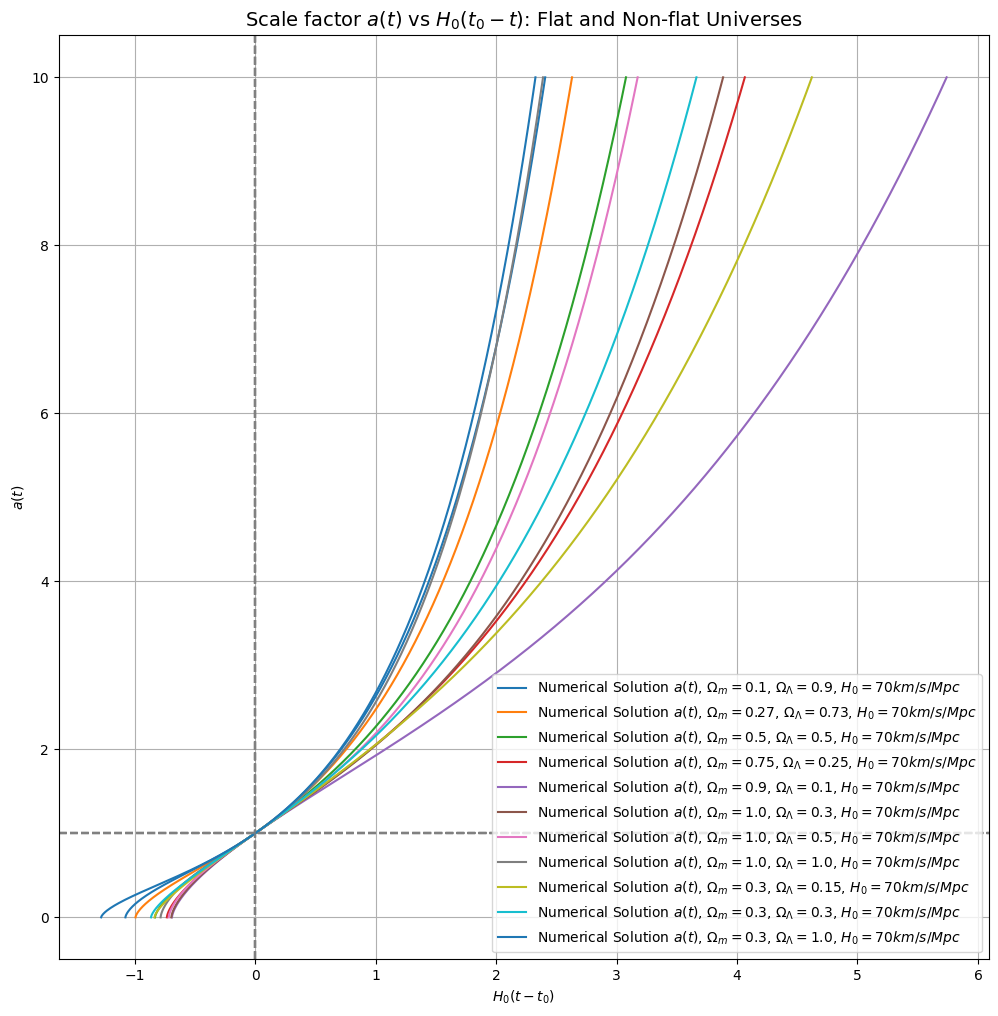

In [ ]:
#Here we plot together all solutions for both flat and non-flat matter+lambda
#universes.
fig, ax = plt.subplots(1,1, figsize=(12,12))

#Plot all solutions:
scale_factor_plot(solution_pairs=solution_mLambda_1, H0=70, omega_m=0.1,
                            omega_Lambda=0.9, t_min=0, ax=ax) #c(i)
scale_factor_plot(solution_pairs=solution_mLambda_2, H0=70, omega_m=0.27,
                            omega_Lambda=0.73, t_min=0, ax=ax) #c(ii)

scale_factor_plot(solution_pairs=solution_mLambda_3, H0=70, omega_m=0.5,
                            omega_Lambda=0.5, t_min=0, ax=ax) #c(iii)

scale_factor_plot(solution_pairs=solution_mLambda_4, H0=70, omega_m=0.75,
                            omega_Lambda=0.25, t_min=0, ax=ax) #c(iv)

scale_factor_plot(solution_pairs=solution_mLambda_5, H0=70, omega_m=0.9,
                            omega_Lambda=0.1, t_min=0, ax=ax) #c(v)

scale_factor_plot(solution_pairs=solution_nonflat_1, H0=70, omega_m=1.0,
                            omega_Lambda=0.3, t_min=0, ax=ax) #d(i)

scale_factor_plot(solution_pairs=solution_nonflat_2, H0=70, omega_m=1.0,
                            omega_Lambda=0.5, t_min=0, ax=ax) #d(ii)

scale_factor_plot(solution_pairs=solution_nonflat_3, H0=70, omega_m=1.0,
                            omega_Lambda=1.0, t_min=0, ax=ax) #d(iii)

scale_factor_plot(solution_pairs=solution_nonflat_4, H0=70, omega_m=0.3,
                            omega_Lambda=0.15, t_min=0, ax=ax) #d(iv)

scale_factor_plot(solution_pairs=solution_nonflat_5, H0=70, omega_m=0.3,
                            omega_Lambda=0.3, t_min=0, ax=ax) #d(v)

scale_factor_plot(solution_pairs=solution_nonflat_6, H0=70, omega_m=0.3,
                            omega_Lambda=1.0, t_min=0, ax=ax) #d(vi)

ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Flat and Non-flat Universes",
             fontsize=14)
ax.legend()
plt.show()

**(f) Bonus Assignment: calculate a universe solution for a negative $Λ$
universe: $Ω_Λ = −0.01$. Explore other negative $Λ$ universes, and discuss
the (numerical) complications this may entail.**

Considering the first FRLW equation, if we have a negative $\Lambda$ universe, then the acceleration of the Universe becomes even more negative, i.e. appart from matter, which gravitationally pulls everything together, now the dark energy also becomes attractive:
\begin{equation}
\ddot{a}=-\frac{4\pi G}{3}(\rho+\frac{3p}{c^2})a + \frac{\Lambda}{3}a.
\end{equation}
This negative Lambda slows down the expansion, but only becomes relevant at sufficiently old times when the contribution of dark energy is considerable and outperforms that of matter.

During this assignment we are applying the following expression to determine $a(t)$:
\begin{equation}
H_0(t-t_\text{min})=
\int_{a_\text{min}}^{a}\frac{1}{\sqrt{\frac{\Omega_{m,0}}{x}+(1-\Omega_0)+\Omega_{\Lambda,0}x^2}}dx
\end{equation}
as stated in question (a), and $\Omega_{r,0}=0$. Since now $\Omega_{\Lambda,0}$ is negative there is a point for sufficiently large $x$ (i.e. $a$) at which the term inside the square root also becomes negative, which yields a numerical failure:

In [ ]:
#Negative Lambda Solution
#Consider a matter-dominated universe with a negative lambda omega_lambda=-0.01
#Apply our original formula
solution_negative_lambda = general_solution(interval_a=[1e-9, 10], N=1000,
                                         omega_m=1, omega_Lambda=-0.01, H0=70, t_min=0)

/tmp/ipython-input-422779792.py:16: RuntimeWarning: invalid value encountered in sqrt
  integrand = lambda x: 1/(np.sqrt(omega_m*(x**-1)+(1-omega_0)+omega_Lambda*(x**2)))
/tmp/ipython-input-422779792.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = integrate.quad(lambda x: integrand(x), interval_a[0], a_j)


To solve this, we first have to determine the value of $a(t)$ at which the square root becomes zero. This is then the maximum value that our scale factor can take ($a_\text{max}$). This precisely means that the Universe now has a maximum expansion. Then we can apply our function $\texttt{general_solution}$ but with the input interval of $a$ running from zero to ($a_\text{max}$).

The square root becomes zero when:
\begin{equation}
\frac{\Omega_{m,0}}{x}+(1-\Omega_0)+\Omega_{\Lambda,0}x^2=0⇔\Omega_{m,0}+(1-\Omega_0)x+\Omega_{\Lambda,0}x^3=0
\end{equation}

In [ ]:
#To determine the value of x at which the square root becomes zero we define
#the following function that finds the roots of this order three polynomial

def a_max_solver(omega_m_0, omega_lambda_0):

  #Total omega_0:
  omega_total_0 = omega_m_0 + omega_lambda_0

  #Coefficients of the order 3 polynomial
  coefficients = [omega_lambda_0, 0, (1-omega_total_0), omega_m_0]

  #Find roots of the polynomoial
  roots =  np.roots(coefficients)

  #Select real root of the equation (complex conjugate come in pairs and this
  #is a polynomial of degree 3)
  a_max = [r.real for r in roots if abs(r.imag) < 1e-8]
  #Now a_max has to be slightly lower (for solution to be numerically computable)
  a_max = np.max(a_max)-1e-9

  return a_max

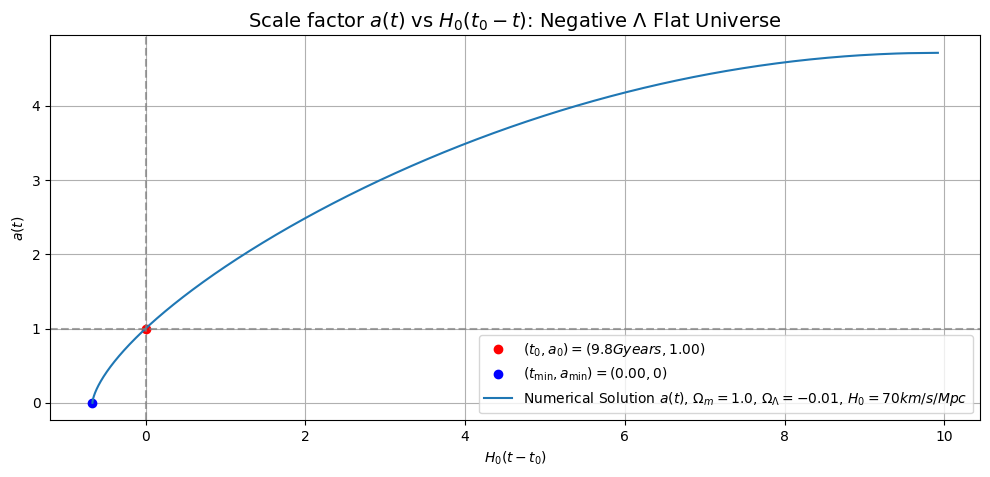

In [ ]:
#For the choice of paramters: omega_m_0=1, omega_lambda_0=-0.01
a_max_trial = a_max_solver(omega_m_0=1, omega_lambda_0=-0.01)

#Generate solution from a=0 to a=a_max
negative_lambda_solution = general_solution(interval_a=[1e-9, a_max_trial], N=1000,
                                         omega_m=1, omega_Lambda=-0.01, H0=70, t_min=0)
#Generate plot
fig, ax = scale_factor_plot(solution_pairs=negative_lambda_solution, H0=70, omega_m=1.0,
                            omega_Lambda=-0.01, t_min=0)


ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Negative $\Lambda$ Flat Universe",
             fontsize=14)
ax.legend()
plt.show()

Now we consider several negative $\Lambda$ universes:


**(i)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (1.1, -0.1)$

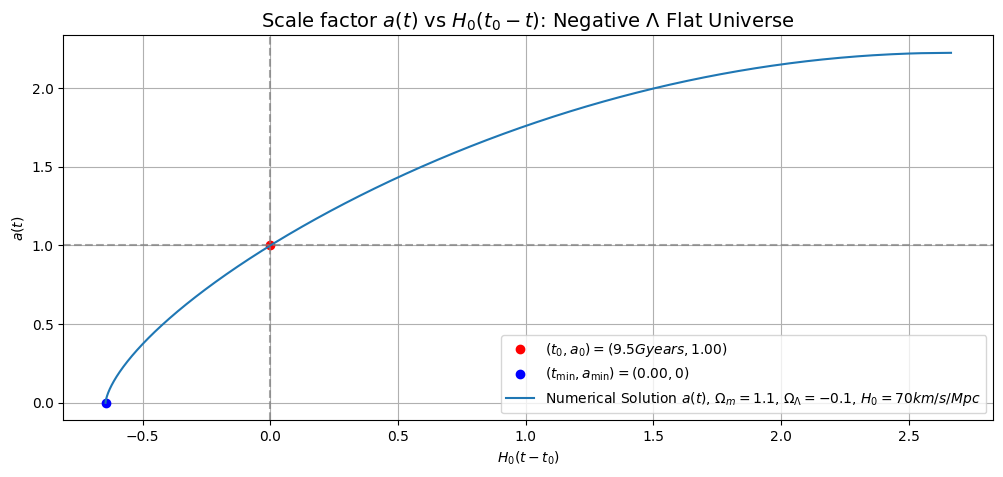

In [ ]:
#For the choice of paramters: omega_m_0=1.1, omega_lambda_0=-0.1
a_max_1 = a_max_solver(omega_m_0=1.1, omega_lambda_0=-0.1)

#Generate solution from a=0 to a=a_max
negative_lambda_solution_1 = general_solution(interval_a=[1e-9, a_max_1], N=1000,
                                         omega_m=1.1, omega_Lambda=-0.1, H0=70, t_min=0)
#Generate plot
fig, ax = scale_factor_plot(solution_pairs=negative_lambda_solution_1, H0=70, omega_m=1.1,
                            omega_Lambda=-0.1, t_min=0)


ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Negative $\Lambda$ Flat Universe",
             fontsize=14)
ax.legend()
plt.show()

**(ii)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (0.9, -0.5)$

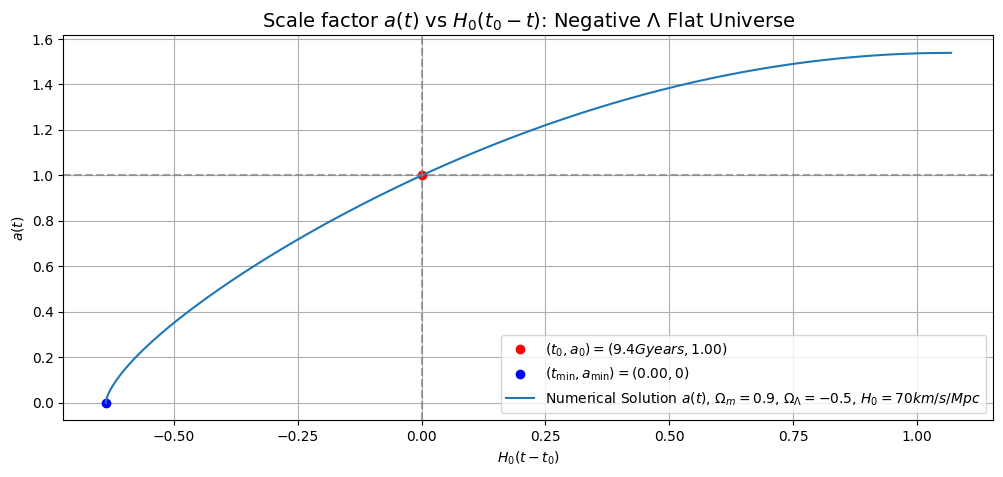

In [ ]:
#For the choice of paramters: omega_m_0=0.9, omega_lambda_0=-0.5
a_max_2 = a_max_solver(omega_m_0=0.9, omega_lambda_0=-0.5)

#Generate solution from a=0 to a=a_max
negative_lambda_solution_2 = general_solution(interval_a=[1e-9, a_max_2], N=1000,
                                         omega_m=0.9, omega_Lambda=-0.5, H0=70, t_min=0)
#Generate plot
fig, ax = scale_factor_plot(solution_pairs=negative_lambda_solution_2, H0=70, omega_m=0.9,
                            omega_Lambda=-0.5, t_min=0)


ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Negative $\Lambda$ Flat Universe",
             fontsize=14)
ax.legend()
plt.show()

**(iii)** $(\Omega_{m,0}, \Omega_{\Lambda,0}) =  (1, -1)$

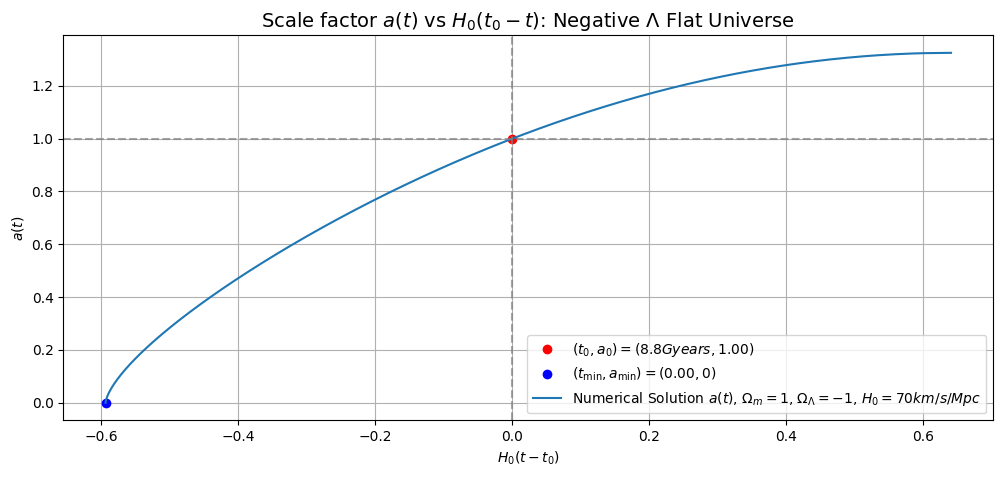

In [ ]:
#For the choice of paramters: omega_m_0=1, omega_lambda_0=-1
a_max_3 = a_max_solver(omega_m_0=1, omega_lambda_0=-1)

#Generate solution from a=0 to a=a_max
negative_lambda_solution_3 = general_solution(interval_a=[1e-9, a_max_3], N=1000,
                                         omega_m=1, omega_Lambda=-1, H0=70, t_min=0)
#Generate plot
fig, ax = scale_factor_plot(solution_pairs=negative_lambda_solution_3, H0=70, omega_m=1,
                            omega_Lambda=-1, t_min=0)


ax.set_title(r"Scale factor $a(t)$ vs $H_0(t_0-t)$: Negative $\Lambda$ Flat Universe",
             fontsize=14)
ax.legend()
plt.show()